# EvoCA — exploration notebook

Tests the C core (ctypes), verifies exact GoL, and launches the SDL2 interactive display.

Run cells in order.  **Build first**, then proceed.

## 1  Build

In [1]:
import subprocess, sys, os
root = os.path.abspath('')
# macOS: gcc -dynamiclib; Linux: gcc -shared
import platform
flag = '-dynamiclib' if platform.system() == 'Darwin' else '-shared'
ext  = 'dylib'      if platform.system() == 'Darwin' else 'so'
cmd  = ['gcc', '-O2', '-Wall', '-fPIC', flag,
        '-o', f'C/libevoca.{ext}', 'C/evoca.c']
r = subprocess.run(cmd, cwd=root, capture_output=True, text=True)
print(r.stdout or '(no stdout)')
if r.returncode != 0:
    print('STDERR:', r.stderr, file=sys.stderr)
    raise RuntimeError('Build failed')
print('Build OK')

(no stdout)
Build OK


## 2  Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import time
from pprint import pprint

from python.evoca_py import EvoCA, make_gol_lut, LUT_BYTES, lut_bit_index
from python.evoca_py import unpack_lut, available_state_init
from python.display  import run as sdl_run
from python.controls import run_with_controls
from python.evoca_py import import_run
from python.controls import available_probes
from python.evoca_explore import evoca_from_scan, evoca_from_scan_top

## 3  Interactive display 

Uses ipywidgets controls + SDL2 window

Controls appear in the cell output below; simulation renders in a separate SDL2 window.

- **Pause / Run** — toggle simulation
- **Step** — single step while paused
- **Quit** — close SDL2 window and return
- **Sliders** — adjust metaparams live; simulation auto-pauses during drag and resumes after
- **Color** dropdown — switch between state / env-food / priv-food views
- SDL2 keyboard: `SPACE` pause · `C` colour · `S` step · `Q`/`Esc` quit

## Available probes

In [5]:
foo = available_probes()
pprint(foo)

{'activity': 'LUT genome activity (scrolling hash-colored strip)',
 'births': 'Mean +/- std of births array',
 'eg_activity': 'Egenome activity (scrolling hash-colored strip)',
 'eg_pop': 'Stacked area: egenome population fractions',
 'entropy': 'Local-pattern Shannon entropy',
 'env_food': 'Mean +/- std of environmental food F(x)',
 'lut_complexity': 'Stacked area: LUT ring-dependency level',
 'n_activity': 'N-activity: Channon shadow LUT-hash strip chart',
 'nq_activity': 'Nq-activity: shadow activity decile strip chart',
 'pat_activity': 'Local-pattern activity (scrolling hash-colored strip)',
 'priv_food': 'Mean +/- std of private food f(x)',
 'q_activity': 'Activity quantile profile (decile strip chart)',
 'ts': 'Grouped time-series: pop, F_mean, f_mean (top) / lut_div, eg_ent, '
       'activity_flux (bottom)'}


In [6]:
pprint(available_state_init())

{'F': "'uniform' (constant) | 'random' (uniform in F_range)",
 'F_init': "float: env food level when F='uniform'. Default 0.0",
 'F_range': "[lo, hi]: range when F='random'. Default [0.0, 1.0]",
 'alive': "'all' | 'fraction' | 'patch' | 'halfplane'",
 'alive_axis': "int 0|1: 0=left half, 1=top half (alive='halfplane'). Default "
               '0',
 'alive_fraction': "float 0-1: fraction alive (alive='fraction'). Default 0.5",
 'alive_radius': "int: half-side of central square (alive='patch'). Default 64",
 'egenome': "'uniform' (same value for all) | 'random' (random in 0..63)",
 'egenome_value': "int 0-63: egenome value when egenome='uniform'. Default 0",
 'f_init': 'float: initial private food per cell. Default 0.0',
 'lut': "'gol' (GoL rule for all) | 'random' (independent random LUT per cell)",
 'lut_n_init': 'int 1-3: ring depth for random LUT (1=10 bits, 2=50, 3=all '
               '250). Default 3',
 'v_density': 'float 0-1: fraction of cells with v=1. Default 0.5'}


In [5]:
gol_lut = make_gol_lut()

In [6]:
dict(N=256, food_inc=0.01, m_scale=1.0, mu_lut=0.0001)

{'N': 256, 'food_inc': 0.01, 'm_scale': 1.0, 'mu_lut': 0.0001}

In [8]:
N = 512
rng2 = np.random.default_rng(0)


#  1. Double m_scale: m_scale=0.4 (cells eat twice as fast → reach 1.0 in roughly the same time they reached 0.5 before)
#  2. Halve tax: tax=0.05 (cells survive longer → more time to accumulate)
#  3. Increase food_inc: food_inc=0.24 (more environmental food → faster eating)
#  4. Combination: e.g., m_scale=0.3, tax=0.07

params = {'N':N,
          'food_inc':0.12,
          'm_scale':0.4,
          'mu_lut':0.01,
          'mu_egenome':0.1,
          'tax':0.05,
          'gdiff': 4,
          'restricted_mu':False}
params_state = dict(lut='random', lut_n_init=1,
                  alive='fraction',
                  alive_fraction=0.5,
                  egenome='uniform',
                    egenome_value=0b000011,
                  f_init=0.1,
                  F_init=0.5)

probes = {'ts': True,
          'eg_activity': True,
          'activity': True,
          'q_activity': True
         }
sim = EvoCA()
sim.init(**params)
sim.state(**params_state)
sim.set_alive_fraction(0.02)
#sim.set_lut_all(gol_lut)
#sim.set_lut_random(n_init=1)
#sim.set_egenome_all(0b000011)
#sim.set_v(rng2.integers(0, 2, (N, N), dtype=np.uint8))
#sim.set_f_all(0.1)
#sim.set_F_all(0.5)

#run_with_controls(sim,paused=True)
#run_with_control(sim, paused=True, probes={'activity':True,'env_food': True, 'priv_food': True})
run_with_controls(sim, probes=probes)
#run_with_controls(sim, probes={'lut_complexity': True, 'activity': True},diag=True)
# Cell returns immediately.  Use widgets or Q/Esc in the SDL2 window to stop.

<Thread(evoca-sim, started daemon 6319370240)>

In [9]:
foo = sim.get_ages()
foo.shape

(512, 512)

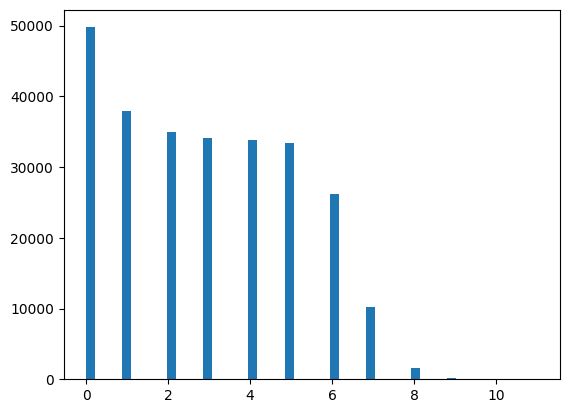

In [13]:
foo=foo.flatten()
plt.hist(foo,bins=50);

In [11]:
foo.shape

(512, 512)

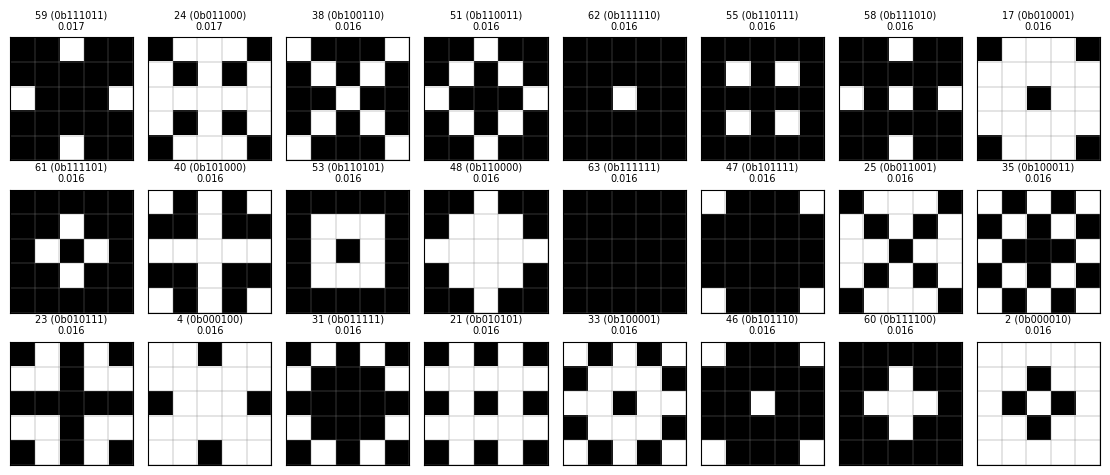

In [6]:
sim.plot_eg(24)


In [7]:
h = sim.get_repro_age_hist()

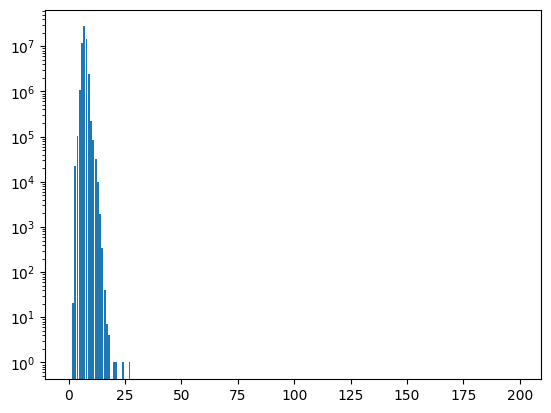

In [8]:
nn=200
plt.bar(range(nn),h[:nn]);
ax=plt.gca()
ax.set_yscale('log')

In [12]:
h[:60]

array([       0,        0,        0,        0,        0,        0,
              0,        0,        0,        0,        0,        0,
              0,        6,       56,      437,     3308,    21682,
         116215,   507114,  1724743,  4623166, 10280849, 25243811,
        6114602,  2359513,   806212,   223672,    57124,    12897,
           3141,      726,      293,       76,       64,        9,
             19,        7,       17,        3,        8,        0,
              3,       47,     4730,    65690,   149594,    30104,
              1,        0,        1,        0,        1,        0,
              0,        0,        1,        0,        0,        0],
      dtype=uint32)

In [32]:
foo=sim_sdl.get_lut(1)
len(foo)

32

In [33]:
foo

array([  0, 128,  15,   0, 248,   0,   4,  15,   4, 248,  64,  64,   1,
         1,  32,   8, 149, 255,   1, 232,  31, 144, 255,  65,  68,  31,
         2, 128,   4,   2,  12,   0], dtype=uint8)

In [22]:
food = sim_sdl.get_F()
len(food)

512

In [18]:
len(food)

0

In [13]:
import seaborn as sns

<Axes: ylabel='Density'>

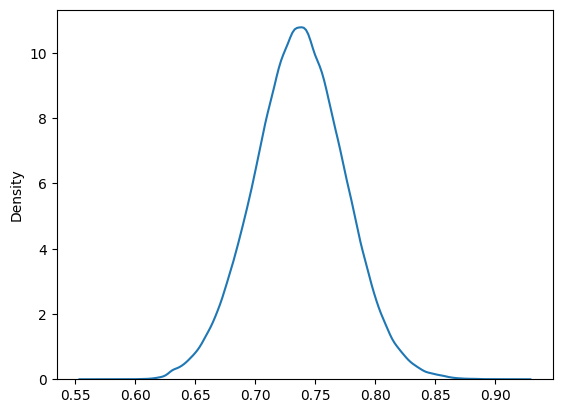

In [23]:
sns.kdeplot(data=food.flatten())

## 4  GoL-only SDL2 display  (food/repro disabled)

Use this to observe pure GoL dynamics with mutation=0.

In [ ]:
N = 512
rng3 = np.random.default_rng(7)

sim_gol = EvoCA()
sim_gol.init(N, food_inc=0.0, m_scale=0.0)
sim_gol.set_lut_all(gol_lut)
sim_gol.set_egenome_all(0)
sim_gol.set_v(rng3.integers(0, 2, (N, N), dtype=np.uint8))
sim_gol.set_f_all(0.0); sim_gol.set_F_all(0.0)

sdl_run(sim_gol)   # blocks until window closed
sim_gol.free()

# test import_run

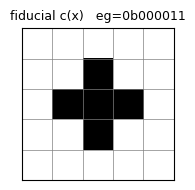

<Thread(evoca-sim, started daemon 6294237184)>

EvoCA SDL: starting  N=512 px=2  probes=['--lut-complexity=psm_341ea6e7']
EvoCA SDL: probe SharedMemory open failed: [Errno 2] No such file or directory: '/--activity=psm_14026cf2'
EvoCA SDL: activity shm opened (256x512)
EvoCA SDL: lut_complexity shm opened (128x512)
EvoCA SDL: SDL_Init OK
EvoCA SDL: window created and raised
EvoCA SDL: 0 probe window(s) created
EvoCA SDL: activity window created
EvoCA SDL: lut_complexity window created
EvoCA SDL: entering main loop


In [6]:
sim, kw = import_run('Runs/2026-03-16_2_branch_activity.evoca')

run_with_controls(sim,**kw)

In [7]:
N = 512
rng2 = np.random.default_rng(0)


#  1. Double m_scale: m_scale=0.4 (cells eat twice as fast → reach 1.0 in roughly the same time they reached 0.5 before)
#  2. Halve tax: tax=0.05 (cells survive longer → more time to accumulate)
#  3. Increase food_inc: food_inc=0.24 (more environmental food → faster eating)
#  4. Combination: e.g., m_scale=0.3, tax=0.07

params = {'N':N,
          'food_inc':0.1,
          'm_scale':0.4,
          'mu_lut':0.01,
          'mu_egenome':0.1,
          'tax':0.05,
          'restricted_mu':False}
params_state = dict(lut='random', lut_n_init=1,
                  alive='halfplane',
                  alive_fraction=0.5,
                  egenome='uniform',
                    egenome_value=0b000011,
                  f_init=0.1,
                  F_init=0.5)

probes = {'ts': True,
          'eg_activity': True,
          'activity': True,
          'q_activity': True
         }
sim = EvoCA()
sim.init(**params)
sim.state(**params_state)
#sim.set_lut_all(gol_lut)
#sim.set_lut_random(n_init=1)
#sim.set_egenome_all(0b000011)
#sim.set_v(rng2.integers(0, 2, (N, N), dtype=np.uint8))
#sim.set_f_all(0.1)
#sim.set_F_all(0.5)

#run_with_controls(sim,paused=True)
#run_with_control(sim, paused=True, probes={'activity':True,'env_food': True, 'priv_food': True})
run_with_controls(sim, probes=probes)
#run_with_controls(sim, probes={'lut_complexity': True, 'activity': True},diag=True)
# Cell returns immediately.  Use widgets or Q/Esc in the SDL2 window to stop.

<Thread(evoca-sim, started daemon 6319026176)>

# Predator-prey / reaction-diffusion waves

NP:

can you help me out with evoca params:
I would like to start with 'alive':'halfplane',
I want to see live cells grow into the empty halfplane where there is food (this happens, no prob),
but I want to see the initial halfplane with live cells develop dead patches because the cells eat food and die,
with food not regenerating fast enough to keep them from dying.  Then after they are dead, the food begins to
accumulate in the dead patchs and provides the necessary resources for the front of live cells to move into the
dead patch.

Can you suggest params to make this happen?

Claude:

Yes — the regime you're describing is a "predator-prey" wave: locally cells eat faster than food regrows, starve,
and the dead patch then refills before the front sweeps back. Two inequalities drive it:

1. tax > food_inc so a dense region's food crashes faster than it regenerates → starvation patches.
2. m_scale × <matches> × F_food ≫ tax when F_food ≈ 1 so frontier cells eating fresh food easily reach f_priv = 1
and reproduce into the empty halfplane.

Here's a starting set, with the reasoning baked in:

import numpy as np
from evoca_py import EvoCA
from controls import run_with_controls
```
N = 256
sim = EvoCA()
sim.init(N,
       food_inc=0.015,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.4,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=0,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.0005,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.0,
       tax=0.05)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 'q_activity': True,
                        'n_activity': True, 'nq_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})
```
What you should see:

- t ≈ 0–10: alive halfplane drains F_food (mouthful 0.2 vs regen 0.015 → drops to ~0 in ~5 steps), and starts
reproducing into the empty side at the boundary.
- t ≈ 10–50: alive cells in the original halfplane starve — f_priv decays at 0.05/step, dies in ~20 steps once
F_food is ~0. Dead patches open up.
- t ≈ 50–120: dead patches refill (≈ 1/food_inc = 67 steps to reach saturation). The advancing front from the
right loops back into the original halfplane.
- Steady state: rolling waves of life/death sweeping across the grid.

Knobs to tune if it's not quite the regime you want:

- Patches too small / starvation too slow → increase tax (e.g. 0.08) or decrease food_inc (e.g. 0.01).
- Front advance too slow → increase m_scale (e.g. 0.6).
- Dead patches stay dead too long → increase food_inc (faster refill).
- Want smoother boundaries → set gdiff=1 (a little food diffusion).

Try it and let me know which way it drifts; I'll re-tune.

In [3]:
N = 512
sim = EvoCA()
sim.init(N,
       food_inc=0.015,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.4,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=0,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.0005,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.0,
       tax=0.05,
        restricted_mu=False)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 'q_activity': True,
                        'n_activity': True, 'nq_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})


<Thread(evoca-sim, started daemon 6282620928)>

EvoCA SDL: starting  N=512 px=2  probes=['env_food', 'priv_food']
EvoCA SDL: activity shm opened (256x512)
EvoCA SDL: q_activity shm opened (9x512)
EvoCA SDL: n_activity shm opened (256x512)
EvoCA SDL: nq_activity shm opened (9x512)
EvoCA SDL: ts shm opened (6 traces)
EvoCA SDL: SDL_Init OK



Death.

**Tweaking claude's suggestion**

In [9]:
N = 512
sim = EvoCA()
sim.init(N,
       food_inc=0.015,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.4,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=0,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.0005,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.0,
       tax=0.02,
        restricted_mu=False)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 'q_activity': True,
                        'n_activity': True, 'nq_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})


EvoCA SDL: exiting cleanly
/Users/n/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/resource_tracker.py:396: UserWarning: resource_tracker: There appear to be 6 leaked shared_memory objects to clean up at shutdown: {'/psm_7675742d', '/psm_9d946b61', '/psm_5e2ebb13', '/psm_aa3bb0c8', '/psm_ed22ca62', '/psm_ba6e009c'}
  warnings.warn(


<Thread(evoca-sim, started daemon 6353022976)>

EvoCA SDL: starting  N=512 px=2  probes=['env_food', 'priv_food']
EvoCA SDL: activity shm opened (256x512)
EvoCA SDL: q_activity shm opened (9x512)
EvoCA SDL: n_activity shm opened (256x512)
EvoCA SDL: nq_activity shm opened (9x512)
EvoCA SDL: ts shm opened (6 traces)


**lower mu_lut to lower drift**

In [10]:
N = 512
sim = EvoCA()
sim.init(N,
       food_inc=0.015,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.5,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=0,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.0001,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.01,
       tax=0.02,
        restricted_mu=True)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 'q_activity': True,
                        'n_activity': True, 'nq_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})


<Thread(evoca-sim, started daemon 6319370240)>

## with diffusion

In [16]:
N = 512
sim = EvoCA()
sim.init(N,
       food_inc=0.02,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.5,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=0.01,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.005,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.001,
       tax=0.025,
        restricted_mu=True)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
#sim.set_F_random(lo=0.6, hi=1.0)   # was set_F_all(1.0)
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 
                        #'q_activity': True,
                        #'n_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})


<Thread(evoca-sim, started daemon 6368325632)>

In [14]:
N = 512
sim = EvoCA()
sim.init(N,
       food_inc=0.02,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.5,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=5,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.001,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.001,
       tax=0.025,
        restricted_mu=True)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
#sim.set_F_random(lo=0.6, hi=1.0)   # was set_F_all(1.0)
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 'q_activity': True,
                        #'n_activity': True, 'nq_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})


<Thread(evoca-sim, started daemon 12935360512)>

EvoCA SDL: starting  N=512 px=2  probes=['env_food', 'priv_food']
EvoCA SDL: activity shm opened (256x512)
EvoCA SDL: q_activity shm opened (9x512)
EvoCA SDL: ts shm opened (6 traces)


In [14]:
# After Run for >100 ticks, then Pause:
print("enabled:", sim.neutral_is_enabled())
print("shadow pop:", sim.neutral_population(), "real pop:", sim.population())
N_tab = sim.get_n_activity(max_n=200000)
print("nact total/live:", len(N_tab['hash']), "/", int((N_tab['pop_count']>0).sum()))
print("nact activity sum:", int(N_tab['activity'].sum()))

enabled: True
shadow pop: 160475 real pop: 160475
nact total/live: 0 / 0
nact activity sum: 0


In [9]:
print("neutral enabled:", sim.neutral_is_enabled())
print("shadow pop:", sim.neutral_population(), "real pop:", sim.population())
N_tab = sim.get_n_activity(max_n=200000)
print("nact total/live:", len(N_tab['hash']), "/", int((N_tab['pop_count']>0).sum()))
print("nact activity sum:", int(N_tab['activity'].sum()))

neutral enabled: True
shadow pop: 163444 real pop: 163444
nact total/live: 13695 / 9998
nact activity sum: 30524768


**discussion with Claude**

**N**

adding diffusion seems to help.
Now does not die.
But diffusion is not creating the patchiness you are expecting.
The environmental food field turns red, with tiny spots of black, some roughly 10x10 roughly circular black
structures.

Definite success:  wave of life going into dead region.  environmental food quickly goes red as the wave enters.
But now new CA dynamics (new colors of CA state) are successfully living in patches.  When dead region has been
fully populated, there are new live patches there bubbling around, old initial live band has bits of dead cells,
and lots of GOL genomes, which converge  to local oscillators as GOL always does.  There are occasional mutations
of new genomes in the GOL region, but vary rarely do they take hold.  But wait... as I write, after 4000 ticks
or so, new islands of non-GOL are forming in original live band of GOL.

Tried going to gdiff=10.  basically same behavior.

**Claude**


⏺ Good — diffusion has done what we needed (sustainability + edge effects). Now the issue is the opposite of before:
with gdiff=5–10, food flows so freely that the dense halfplane gets resupplied from the empty side and never has
to starve. The math:

Why no widespread death now: at quasi-equilibrium with high diffusion, total eating ≈ total regen, so
per-alive-cell intake ≈ food_inc × N_cells / N_alive. With halfplane init that's food_inc / 0.5 = 2·food_inc =
0.040, well above your tax = 0.025. So the system happily sustains 50% density, with localized starvation only
where heterogeneity (CA dynamics, mutation, edge geometry) creates an imbalance — hence the small ~10×10 black
patches you're seeing instead of large dying regions.

To get larger / more aggressive dying patches in the dense halfplane, throttle the food-sharing or raise the death
pressure:
```
sim.update_gdiff(2)            # was 10 — less interior support
sim.update_tax(0.030)          # was 0.025
sim.update_food_inc(0.015)     # was 0.020
```

The new balance:
- Per-cell intake at 50% density = 0.015 / 0.5 = 0.030 = tax exactly. Right at the edge of sustainability —
fluctuations now matter.
- Dense interior cells (>50% local density, getting less than their fair share via gdiff=2) cross into deficit and
die.
- Frontier / sparse cells still get a diffusion bonus and survive.
- That's the "patches die, frontiers move" wave you wanted.

If patches still don't grow large, increment tax to 0.035 or drop food_inc to 0.010. If everything dies again,
walk back: gdiff=3, tax=0.028, food_inc=0.018.

---
Side note on what you observed at t≈4000: non-GoL islands forming inside the GoL region — that's the actual
interesting science here, evolution finding a higher-fitness variant under selection pressure. The current low-mu
regime makes such takeovers rare, which is why you're seeing isolated islands rather than sweeps. If you want to
study how often / how fast novel genomes invade, raise mu_lut to ~0.005 in a separate run — at the cost of GoL
coherence, you'll see far more frequent invasion attempts and clearer competitive dynamics. Worth having both
regimes (low-mu / high-mu) as named parameter sets.

Want me to tag a follow-up to /schedule a quick agent in a week to revisit param ranges once you've got a feel for
the wave / no-wave / evolution boundaries? Or skip and tune live next session?

✻ Worked for 1m 21s

**N**

❯ also visible at t~4000, some grid structure of dead cells seem to form in the evolving patches  dead bands one
cell wide, both horizontal and vertical, separated by 3 or 4 live cells in between.

**Claude**

⏺ That grid pattern is exactly what you'd predict if selection has discovered a food-channel strategy. Here's the
mechanism I'd bet on:

Why the grid is favored: with gdiff > 0, an alive cell adjacent to a dead cell receives ~`F_food/9extra each step
from its dead-neighbor's food (via the box blur). A genome variant that arranges for some cells to consistently
die — but in a regular dead-band-every-3-or-4-cells geometry — gives every surviving cell ≥1 dead neighbor, so the
whole live strip gets a permanent diffusion subsidy. It's the evolutionary equivalent of a fallow row in a crop
field. The dead cells get continuously re-populated by reproduction (they're the f_priv=0 sinks), but then
immediately re-starve because some combination of (egenome, local v_curr) gives them very lowmatches` — so they're
a "birth-and-die" turnover layer that functions as a food channel.

Why 3–4 cells: that spacing should be set by the diffusion length over the death timescale. With gdiff=2 (or your
current value), food in a dead band reaches ~2 cells deep before the eating drains it; spacing of 3–4 makes every
live cell within reach of two opposite dead bands. If you raise gdiff to 5 you should see the spacing widen to
~5–6 cells. That's the cleanest test of the mechanism.

To probe it further:
- Crank gdiff to 5 and re-watch a fresh patch — if grid spacing scales, the food-channel theory is right.
- Crank gdiff to 0 — grid should disappear (no diffusion subsidy → no benefit to fallow bands).
- Use bug-coloring on cells inside vs on the band — they should have different genomes (the band cells are getting
overwritten by edge cells with the channel-favoring genome but their own rule keeps mismatching the local
v_curr).
- Watch the N-activity / G-activity windows: a grid-patch that's evolved a coherent strategy should show up as a
single fat G-activity bucket sustaining over thousands of ticks, way above the N-activity (shadow) band.

This is the kind of emergent spatial cooperation the system was designed to surface. Worth saving the seed +
params for that 4000-tick run as a recipe — once you confirm the gdiff-scaling test, it'd make a great figure.

✻ Worked for 56s

**N**

❯ I am confused about the black band structure:  in the env food field, I also see black bands, but why?  I would
expect food to grow happily back to green when there are black bands (dead cells).

**Claude**

⏺ Counterintuitive but correct: with gdiff > 0, dead cells don't accumulate food locally. Here's the equilibrium
math.

Diffusion equalises the F_food field across the patch on a timescale of one or two steps. Once it's nearly
uniform, the cell-level balance per step (regen − consumed) has to net to zero or F drifts. With diffusion fast
enough to mix the field, the equilibrium reduces to a spatial average:

food_inc           ≈   tax × alive_density
(per cell, regen)      (per cell, consumed in steady state)

With your food_inc = 0.020, tax = 0.030: equilibrium alive density ≈ 0.020 / 0.030 = 67%. The system has settled
there — and at that density, the steady-state F_food (the value where mouthful = tax) is tax / (m_scale/25 ×
matches) = 0.030 / 0.4 ≈ 0.075.

So the whole F_food field is dim (~7% of full saturation), uniformly, including the dead bands. The "black bands"
you see aren't really cells with no food — they're cells with the same low food everywhere, just lacking the
alive-cell red overlay that the live strips have on top. Strip away the overlay and the strips look the same dim
green as the bands.

Why no green-refilling: the dead bands do gain food_inc = 0.02/step from regen, but the diffusion pulls that food
right back out into the surrounding live cells (which are food sinks). A 1-wide dead band surrounded by live cells
loses ~8/9 of its accumulated food per diffusion pass. With gdiff = 2, that's 99% drained per step. The bands
operate as steady food channels, not reservoirs.

Test the explanation in two ways:

1. Look at the raw values: F = sim.get_F(); print(F.min(), F.mean(), F.max()). You should see all three close
together around ~0.05–0.10. The bands won't be appreciably lower than the strips.
2. Set gdiff = 0 for a cycle: dead bands will start to fill toward green individually (at rate 0.02/step) because
there's no diffusion to drain them. You'll lose the food-channel mechanism and probably the grid pattern within a
few hundred ticks, but the visual will match your intuition.

The visualization is genuinely misleading here — the "black bands" suggest dead cells with no food, but they're
really alive cells' missing-overlay revealing the universally-low background.

**N**

❯ Your theory re length scales for the channels of dead cells does not seem to pan out.

I raise gdiff=20 and see definitely larger scale dead cell structure  in the initial live band after  GOL goes
through its transient.  But over in the live patches, I still see the dead bands separated by 3 live cells.  But
also some regions with labyrinthine structures of live cells that seem to persist with their 1-state mostly on
for long periods of time, with interstices of dead and/or 0 cells.

**Claude**

⏺ You're right, I overreached on the diffusion-length theory. The fact that band spacing is invariant under gdiff=20
means it's not set by the food field at all — it's set by the CA dynamics of the evolved LUT itself. Updated
hypothesis:

The genome in those patches has been selected to produce a CA whose v_curr field has an intrinsic spatial period
of ~4 cells (1 zero-column, 3 one-columns). The "dead bands" emerge because at the v=0 columns the local 5×5 nbhd
doesn't match the fiducial well → matches → 0 → no eating → starvation. So the spacing is encoded in the LUT, with
diffusion just permitting survival overall. That cleanly explains why pumping gdiff up to 20 doesn't move the
spacing — you're varying the wrong knob.

The GoL transient region reverts to a different scale because GoL has its own intrinsic wavelengths (gliders,
blinkers, oscillator zoo, all on different scales) and never settled into a Turing-pattern attractor like the
evolved patches did.

The labyrinthine v=1 structures are the giveaway: an LUT with stable striped / labyrinthine attractors is a
classic pattern-forming CA (think Turing-stripes-as-CA). Selection found one because cells inside such a pattern
get a steady food subsidy from the v=0 interstices.

Tests that would settle it:

1. Snapshot one evolved-patch cell's LUT and broadcast it across a fresh grid:
```
lut_arr = sim.get_lut(idx_in_patch).copy()
fresh = EvoCA(); fresh.init(N, food_inc=…, …)
fresh.set_lut_all(lut_arr)
fresh.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
fresh.set_alive_all()
# run a few hundred ticks
```

1. If the same 4-cell stripe pattern appears across the whole grid, the LUT alone explains it.
2. Vary gdiff over a wide range with that fixed LUT. If band spacing stays at 3 live cells, it's purely
genome-driven. (This is the experiment you basically just did, but with a controlled genome.)
3. Look at G-activity / Gq-activity for these patches: a single LUT genome dominating a stable patch should show
one fat persistent G-activity bucket. The N-activity (shadow) shouldn't show anything similar because random
selection doesn't preserve spatial-pattern strategies.

What you're watching now is much more interesting than the wave-of-death dynamic I was trying to engineer — it's
the CA evolving toward pattern-forming attractors that exploit the food-economics. The "10×10 black structures"
you saw earlier may be a different pattern-forming variant; the labyrinths are another. Probably worth a permanent
named-recipe save of the seed + params before you keep tweaking. Want me to /schedule a follow-up agent in 1–2
weeks to come back and document these regimes once you've cataloged a few?


In [ ]:
N = 512
sim = EvoCA()
sim.init(N,
       food_inc=0.025,   # slow regrowth  (~67 steps to refill an empty cell)
       m_scale=0.4,      # max mouthful ≈ 0.4 × 0.5 × F_food = 0.2 × F_food
       gdiff=5,          # no food diffusion → keep dead patches well-defined
       mu_lut=0.001,    # tiny mutation; keeps GoL essentially intact
       mu_egenome=0.001,
       tax=0.0204,
        restricted_mu=True)         # > food_inc → dense regions starve
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive

run_with_controls(sim, paused=True,
                probes={'activity': True, 'q_activity': True,
                        'n_activity': True, 'nq_activity': True,
                        'env_food': True, 'priv_food': True, 'ts': True})


In [15]:
import_run()

2026-03-16_2_branch_activity.evoca
2026-04-25_waves_in_blank_half.evoca


['/Users/n/Projects/EvoCA/Runs/2026-03-16_2_branch_activity.evoca',
 '/Users/n/Projects/EvoCA/Runs/2026-04-25_waves_in_blank_half.evoca']

In [7]:
sim, params = import_run("Runs/2026-04-25_waves_in_blank_half.evoca",recipe='final')

In [8]:
sim.N

512

In [26]:
rng = np.random.default_rng(0)
N=sim.N
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5)         # cells start half-full so they eat & breed quickly
sim.set_F_all(1.0)         # food field starts saturated everywhere
sim.set_alive_halfplane(0) # left half alive
run_with_controls(sim,**params)

<Thread(evoca-sim, started daemon 6268039168)>

EvoCA SDL: starting  N=512 px=2  probes=['env_food', 'priv_food']
EvoCA SDL: activity shm opened (256x512)
EvoCA SDL: q_activity shm opened (9x512)
EvoCA SDL: n_activity shm opened (256x512)
EvoCA SDL: nq_activity shm opened (9x512)
EvoCA SDL: ts shm opened (6 traces)


In [10]:
sim.params()

{'N': 512,
 'food_inc': 0.025,
 'm_scale': 0.4,
 'gdiff': 0,
 'mu_lut': 0.05,
 'mu_egenome': 0.2,
 'tax': 0.0204,
 'restricted_mu': 1}

# Search for reaction diffusion waves

**N**

❯ I basically agree with your contention:  we have successfully found a regime of ongoing interesting evolution.

But...

I still think we should be able to see waves somehow.  You called them predator-prey waves.  I have called them
(in other model contexts, eg genelife) reaction diffusion waves.  Anyway, such waves are intuitively to be
expected; I'm surprised we can't see them easily.

**Claude**

⏺ I think you're right that the intuition is correct — consumer-resource + diffusion + finite recovery time should
produce R-D waves. The fact that we can't elicit them easily is probably telling us about specific structural
choices in EvoCA that damp the oscillation. Three candidates:

1. No refractory delay. Classical R-D oscillations (BZ, FitzHugh-Nagumo, predator-prey waves in genelife if I
remember the lattice variant correctly) require a delay between consumption and re-availability — either a slow
reaction intermediate, or a recovery period during which the resource genuinely cannot be re-consumed. In EvoCA,
food regen and eating happen in the same step on the same field. No delay means perturbations decay rather than
propagate as oscillations.

2. Reproduction-as-migration, not local growth. When a cell hits f_priv ≥ 1, the child goes to the minimum-f_priv
neighbor — by construction, offspring move from rich → poor regions. That's a Fisher-KPP-style flux operator:
dense regions monotonically seed sparse ones, but there's no mechanism for a dense region to crash in place and
refill. Cells just emigrate as conditions deteriorate. Compare to most classical R-D systems where the "predator"
stays put and overshoots locally before crashing.

3. Selection actively prefers stable solutions. This is the deepest factor. The garden-plot pattern you saw isn't
accidental — once a non-trivial mutation rate is on, evolution finds attractors that are stable (= survive).
Oscillating regimes are by definition less stable than fixed-point ones, so over evolutionary time the system
slides off them. R-D waves in pre-evolutionary models (where genome doesn't adapt) don't have this issue. In
genelife, I'd bet either the genome doesn't directly modulate reproduction efficiency, or the timescales of
evolution and oscillation are well separated.

What I'd try, in roughly increasing-effort order:

- Sparse random init (set_alive_fraction(0.02) instead of halfplane). Spatially heterogeneous starting density may
seed local fronts that interact rather than smoothing into a uniform sea.
- Disable evolution for a probe run: mu_lut=0, mu_egenome=0. Lock the LUT to GoL and see whether non-evolutionary
R-D dynamics work in this model. If you see waves there but not with evolution on, point #3 is dominant. If you
see no waves there either, points #1–2 are.
- Add a refractory mechanism — small C-level change: a per-cell "regen cooldown" counter such that a cell that
just had its food eaten or a cell that just died can't gain food for K steps. This directly inserts the missing
delay. Easily reversible if it doesn't help.

If you've seen R-D waves cleanly in genelife with comparable primitives, it'd be useful to look back at what those
primitives actually were — odds are decent that one of #1 or #2 is the structural difference. Want me to sketch
the refractory cooldown patch as a switch you can toggle on/off, so we can find out empirically?

# debug

In [2]:
import numpy as np
from python.evoca_py import EvoCA
N = 512
sim = EvoCA()
sim.init(N, food_inc=0.02, m_scale=0.5, gdiff=5,
       mu_lut=0.001, mu_egenome=0.001, tax=0.025, restricted_mu=True)
sim.state(lut='gol', egenome='uniform', egenome_value=0b000011)
rng = np.random.default_rng(0)
sim.set_v(rng.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.5); sim.set_F_all(1.0)
sim.set_alive_halfplane(0)
sim.neutral_enable()
print("alive:", sim.population(), "shadow:", sim.neutral_population())
for t in range(200):
  sim.step()
  sim._lib.evoca_n_activity_update()
N_tab = sim.get_n_activity(max_n=200000)
print("N total:", len(N_tab['hash']), "live:", int((N_tab['pop_count']>0).sum()))

alive: 131072 shadow: 131072
N total: 13950 live: 10163
